[SNOTEL] Loading stations metadata from egagli/snotel_ccss_stations...
[SNOTEL] Using stations:
  - Beaver Pass (990_WA_SNTL)
  - Brown Top (1080_WA_SNTL)
  - Marten Ridge (999_WA_SNTL)
  - Rainy Pass (711_WA_SNTL)
  - Swamp Creek (975_WA_SNTL)
  - Thunder Basin (817_WA_SNTL)

=== SNOTEL mean annual precipitation (mm) ===
2014: 2749.9 mm
2015: 2219.5 mm
2016: 2300.7 mm
2017: 2158.4 mm
2018: 1905.3 mm
2019: 1368.8 mm
2020: 2114.5 mm

PNNL mask array shape: (450, 450)   Basin cells: 228

[PNNL] Year 2014 → 1 file(s)
  PNNL precip dims: ('time', 'x', 'y') shape: (8760, 450, 450)
  Annual field min/max: 0.0 5454.7705078125
  [PNNL] Skagit basin annual precip 2014: 2366.1 mm

[PNNL] Year 2015 → 1 file(s)
  PNNL precip dims: ('time', 'x', 'y') shape: (8760, 450, 450)
  Annual field min/max: 0.0 5943.8974609375
  [PNNL] Skagit basin annual precip 2015: 2188.5 mm

[PNNL] Year 2016 → 1 file(s)
  PNNL precip dims: ('time', 'x', 'y') shape: (8784, 450, 450)
  Annual field min/max: 0.0 5935.355468

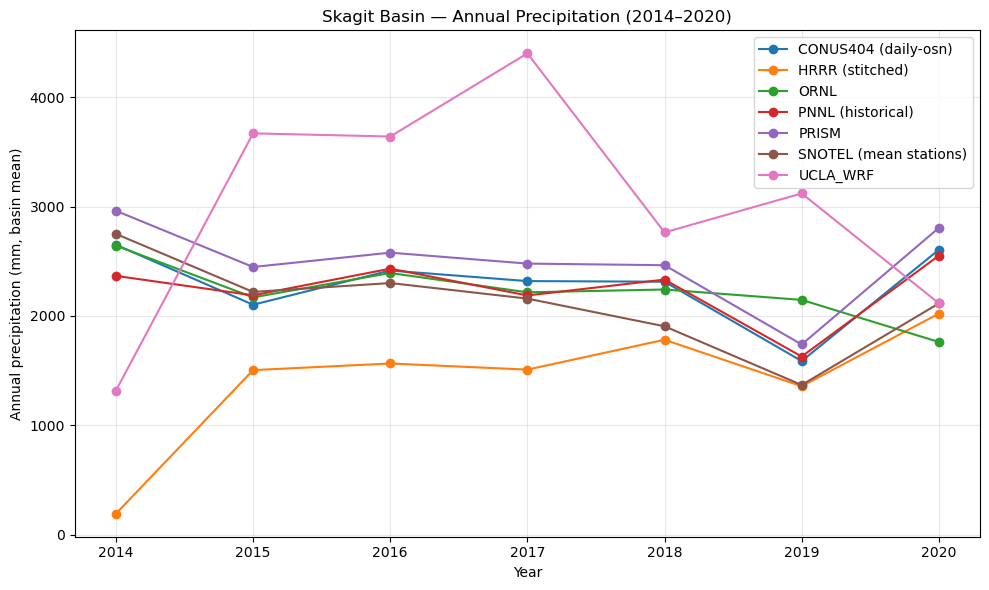

In [1]:
# ============================
# Skagit Basin — Annual Precip (mm) by dataset (2014–2020)
# Safe, de-accumulating where needed, robust to duplicates
# ============================
import json, re, os
from pathlib import Path
from glob import glob
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ---------------- Config ----------------
BASE = Path("/data0/balaji24/data")
BOUNDARY_GEO  = Path("../data/GIS/SkagitBoundary.json")

YEAR_MIN, YEAR_MAX = 2014, 2020

# dataset roots
P_ORNL_DIR   = BASE / "ornl"
P_PRISM_DIR  = BASE / "prism_ppt"
P_HRRR_DIR   = BASE / "weather_data"             # expect many *_HRRR_data.zarr months
P_WRF_DIR    = BASE / "ucla_wrf_outputs"         # annual zarrs
P_SNOTEL_DIR = BASE / "snotel"                   # monthly zarrs
PNNL_HIST    = BASE / "PNNL" / "historical"      # hourly NetCDFs per year
PNNL_GEO     = BASE / "PNNL" / "SERDP6km.geo_em.d01.nc"

# our derived CONUS404 Zarr (from your previous step)
P_CONUS_DERIVED = BASE / "derived" / "conus404_skagit_precip_daily.zarr"

OUT = BASE / "derived"
OUT.mkdir(parents=True, exist_ok=True)
CSV_OUT = OUT / "annual_precip_skagit_2014_2020_ALL.csv"
PNG_OUT = OUT / "annual_precip_skagit_2014_2020_ALL.png"

# ---------------- Helpers ----------------
def safe_open_zarr(p):
    try:
        return xr.open_zarr(p, consolidated=True)
    except Exception:
        return xr.open_zarr(p, consolidated=False)

def find_lat_lon_names(ds):
    lat_name = next((n for n in ["lat","latitude","XLAT","XLAT_M"] if n in ds), None)
    lon_name = next((n for n in ["lon","longitude","XLONG","XLONG_M"] if n in ds), None)
    return lat_name, lon_name

# Load polygon
def _load_boundary_geom():
    from shapely.geometry import shape, Polygon, LinearRing
    with open(BOUNDARY_GEO) as f:
        obj = json.load(f)
    if isinstance(obj, dict) and "type" in obj:
        if obj["type"] == "FeatureCollection":
            return shape(obj["features"][0]["geometry"])
        elif obj["type"] == "Feature":
            return shape(obj["geometry"])
        else:
            return shape(obj)
    elif isinstance(obj, dict) and {"lon","lat"} <= obj.keys():
        pts = list(zip(obj["lon"], obj["lat"]))
        if pts[0] != pts[-1]:
            pts.append(pts[0])
        return Polygon(LinearRing(pts))
    raise ValueError("Unrecognized boundary format")

# Build a regionmask mask on a dataset that *has* 2D lon/lat
def skagit_mask(ds_with_latlon):
    try:
        import regionmask, geopandas as gpd
    except Exception:
        return None

    lat_name, lon_name = find_lat_lon_names(ds_with_latlon)
    if not (lat_name and lon_name):
        return None

    def _to_2d(arr):
        # Drop a time dim if present (take first slice; grid is static)
        if "time" in arr.dims:
            arr = arr.isel(time=0)
        # Squeeze any length-1 dims
        for d in list(arr.dims):
            if arr.sizes[d] == 1:
                arr = arr.isel({d: 0})
        # If still >2D (rare), try to pick the first index along extra dims
        while arr.ndim > 2:
            extra = [d for d in arr.dims if d not in ("x","y","lon","lat")]
            if not extra:
                break
            arr = arr.isel({extra[0]: 0})
        return arr

    lon = _to_2d(ds_with_latlon[lon_name])
    lat = _to_2d(ds_with_latlon[lat_name])

    # Load basin polygon
    from shapely.geometry import shape
    with open(BOUNDARY_GEO) as f:
        obj = json.load(f)
    if obj.get("type") == "FeatureCollection":
        geom = shape(obj["features"][0]["geometry"])
    elif obj.get("type") == "Feature":
        geom = shape(obj["geometry"])
    else:
        geom = shape(obj)

    try:
        regions = regionmask.Regions.from_geopandas(
            gpd.GeoDataFrame({"name":["Skagit"]}, geometry=[geom], crs="EPSG:4326"),
            names="name",
        )
    except AttributeError:
        regions = regionmask.Regions(outlines=[geom], names=["Skagit"], numbers=[0], name="Skagit")

    # regionmask wants (lon, lat) in 1D/2D
    m = regions.mask(lon, lat)   # NaN outside, 0 inside
    return m.isnull() == False   # True inside

def ensure_time_sorted_unique(da):
    if "time" not in da.dims:
        return da
    da = da.sortby("time")
    try:
        # drop duplicate time stamps if any (avoid Pandas dtype casts on dask)
        t = xr.DataArray(da["time"].values)
        _, idx = np.unique(t.values, return_index=True)
        da = da.isel(time=np.sort(idx))
    except Exception:
        pass
    return da

def to_incremental_mm(da, force_cumulative=False):
    """
    Normalize precip to *incremental per step* in mm.
    - Converts units if possible.
    - If cumulative/resetting, de-accumulate with clipping.
    """
    units = str(da.attrs.get("units", "")).lower()
    name  = (da.name or "").lower()

    # convert meters to mm
    if units.strip() in {"m", "meter", "meters"}:
        da = da * 1000.0
        da.attrs["units"] = "mm"

    # kg m^-2 ≈ mm
    if "kg m" in units and "-2" in units:
        da.attrs["units"] = "mm"

    # decide cumulative
    is_cum = (
        force_cumulative
        or any(k in name for k in ["prec_acc_nc","rainnc","rainc","acc"])
        or ("cumulative" in units)
    )

    da = ensure_time_sorted_unique(da)

    if is_cum:
        inc = da.diff("time", label="upper")
        inc = inc.where(inc >= 0, 0)  # clip resets
        # prepend 0 at first timestep
        inc = xr.concat([da.isel(time=slice(0,1))*0, inc], dim="time")
        inc.attrs["units"] = "mm"
        return inc

    # treat as already per-step (e.g., mm/hour or mm/day in input)
    return da

def basin_mean(da, grid_ds=None):
    """
    Basin-average on the field's native grid using a Skagit mask.
    If grid_ds is provided, use its lat/lon to build the mask.
    """
    time_dim = next((d for d in da.dims if np.issubdtype(da[d].dtype, np.datetime64)), "time")
    spatial = [d for d in da.dims if d != time_dim]
    if not spatial:
        return da

    host = grid_ds if grid_ds is not None else da.to_dataset(name="_tmp")
    mask = skagit_mask(host)
    if (mask is None) or (set(mask.dims) != set(spatial)):
        # fallback plain mean if we cannot mask for some reason
        return da.mean(spatial, skipna=True)

    w = xr.where(mask, 1.0, np.nan)
    return (da * w).mean(spatial, skipna=True)

def annual_sum_mm(da):
    """Sum to annual (mm). Uses xarray .dt.year to avoid pandas casting issues."""
    if "time" not in da.dims:
        out = xr.DataArray(da)
        out = out.rename("mm")
        return out
    years = da["time"].dt.year
    out = da.groupby(years).sum("time")
    out = out.rename({"group": "year"}) if "group" in out.dims else out
    # If xarray keeps a coord name like 'time_year', normalize it:
    if "time.year" in out.coords:
        out = out.rename({"time.year": "year"})
    out.name = "mm"
    return out

def pick_year(ann, yr):
    try:
        # support either a 'year' coord or a bare coordinate
        if "year" in ann.coords:
            return float(ann.sel(year=yr).values)
        # fallback if the coord is named something else:
        for c in ann.coords:
            if "year" in str(c):
                return float(ann.sel({c: yr}).values)
        return float(ann.values.item())  # single value
    except Exception:
        return np.nan

# --------- Extra helpers for HRRR (from your robust block) ----------
def deaccumulate_generic(da, time_dim="time", clip_zero=True):
    """
    Turn a cumulative series into per-step increments.
    Works with plain 'time' or per-run accumulations if 'run'/'step' exist.
    """
    run_coord = next((c for c in ("run","init","forecast_reference_time") if c in da.coords), None)
    step_coord = next((c for c in ("step","lead","forecast_hour") if c in da.coords), None)
    if run_coord and step_coord:
        dif = da.sortby([run_coord, step_coord]).diff(step_coord, label="upper")
        if clip_zero:
            dif = xr.where(dif < 0, 0, dif)
        return dif.fillna(0)

    da = da.sortby(time_dim)
    dif = da.diff(time_dim, label="upper")
    if clip_zero:
        dif = xr.where(dif < 0, 0, dif)
    return dif.fillna(0)

def hrrr_hourly_precip_mm(ds, var="tp"):
    """
    Return hourly precipitation increments in mm from HRRR.
    Detects cumulative vs incremental and handles resets.
    """
    da = ds[var]
    # Heuristic: if monotonic along a short slice, treat as cumulative
    probe = da.isel({k:0 for k in da.dims if k not in ("time","step")})
    vals = probe.values
    is_cum = False
    if getattr(vals, "ndim", 0) == 1 and vals.size > 6:
        dif = np.diff(vals[:200] if vals.size > 200 else vals)
        is_cum = (dif >= -1e-6).mean() > 0.9
    return deaccumulate_generic(da, time_dim="time", clip_zero=True) if is_cum else da

# ---------------- Collectors ----------------
rows = []

# ---------- ORNL (Daymet: mm/day) ----------
if P_ORNL_DIR.exists():
    ornl_years = sorted(P_ORNL_DIR.glob("*_ORNL_data.zarr"))
    if ornl_years:
        dso = xr.concat(
            [safe_open_zarr(p) for p in ornl_years],
            dim="time",
            join="outer",
            coords="minimal",
            compat="override",
        )
        if "prcp" in dso:
            da = ensure_time_sorted_unique(dso["prcp"])  # mm/day
            bm = basin_mean(da, grid_ds=dso)
            ann = annual_sum_mm(bm)
            for yr in range(YEAR_MIN, YEAR_MAX+1):
                val = pick_year(ann, yr)
                if not np.isnan(val):
                    rows.append({"dataset":"ORNL", "year": yr, "mm": val})

# ---------- PRISM (daily zarrs; ppt ~ mm/day) ----------
if P_PRISM_DIR.exists():
    prism_years = sorted(P_PRISM_DIR.glob("**/*_daily_4km_PRISM_data.zarr"))
    if prism_years:
        dsp = xr.concat(
            [safe_open_zarr(p) for p in prism_years],
            dim="time",
            join="outer",
            coords="minimal",
            compat="override",
        )
        v = next((v for v in ["ppt","precip","prcp"] if v in dsp), None)
        if v:
            da = ensure_time_sorted_unique(dsp[v])  # mm/day
            bm = basin_mean(da, grid_ds=dsp)
            ann = annual_sum_mm(bm)
            for yr in range(YEAR_MIN, YEAR_MAX+1):
                val = pick_year(ann, yr)
                if not np.isnan(val):
                    rows.append({"dataset":"PRISM", "year": yr, "mm": val})

# ---------- HRRR (stitched monthly zarrs; robust de-accumulation) ----------
hrrr_months = sorted(P_HRRR_DIR.glob("*.zarr"))
if hrrr_months:
    # Keep only files like YYYY-MM_HRRR_data.zarr
    monthly = [p for p in hrrr_months if re.match(r"\d{4}-\d{2}_HRRR_data\.zarr", p.name)]
    for yr in range(YEAR_MIN, YEAR_MAX + 1):
        parts = [p for p in monthly if p.name.startswith(f"{yr}-")]
        if not parts:
            continue
        dsets = [safe_open_zarr(p) for p in parts]
        ds = xr.concat(dsets, dim="time", join="outer", coords="minimal").sortby("time")

        var = "tp" if "tp" in ds else ("apcp" if "apcp" in ds else None)
        if not var:
            # close any opened pieces before skipping
            for d in dsets:
                d.close()
            continue

        hourly_mm = hrrr_hourly_precip_mm(ds, var=var)   # increments in mm
        daily     = hourly_mm.resample(time="1D").sum()   # daily totals
        bm        = basin_mean(daily, grid_ds=ds)         # basin mean
        ann       = bm.groupby("time.year").sum(skipna=True)  # annual

        if "year" in ann.coords and (yr in ann["year"].values):
            rows.append({"dataset":"HRRR (stitched)", "year": yr, "mm": float(ann.sel(year=yr).values)})

        # close to free handles
        for d in dsets:
            d.close()

# ---------- UCLA WRF (yearly zarrs; RAINNC/RAINC cumulative mm with resets) ----------
if P_WRF_DIR.exists():
    wrf_zarrs = sorted(P_WRF_DIR.glob("*.zarr"))
    for z in wrf_zarrs:
        m = re.search(r"(\d{4})", z.name)
        yr = int(m.group(1)) if m else None
        if yr is None or not (YEAR_MIN <= yr <= YEAR_MAX):
            continue
        dsw = safe_open_zarr(z)
        v_nc = next((n for n in ["RAINNC","rainnc"] if n in dsw), None)
        v_c  = next((n for n in ["RAINC","rainc"] if n in dsw), None)
        if not (v_nc or v_c):
            continue
        total = None
        for vv in [v_nc, v_c]:
            if vv:
                inc = to_incremental_mm(dsw[vv], force_cumulative=True)  # diff + clip
                total = inc if total is None else total + inc
        total = ensure_time_sorted_unique(total)
        daily = total.resample(time="1D").sum()
        bm = basin_mean(daily, grid_ds=dsw)
        ann = annual_sum_mm(bm)
        val = pick_year(ann, yr)
        if not np.isnan(val):
            rows.append({"dataset":"UCLA_WRF", "year": yr, "mm": val})

# ---------- SNOTEL (GitHub egagli repo; mean of Skagit stations) ----------
try:
    import geopandas as gpd
    import shapely.geometry as sgeom
    import requests
except ImportError as e:
    print(f"[SNOTEL] Missing dependency ({e}), skipping SNOTEL.")
else:
    print("[SNOTEL] Loading stations metadata from egagli/snotel_ccss_stations...")

    stations_url = (
        "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/"
        "all_stations.geojson"
    )

    # --- load GeoJSON WITHOUT gpd.read_file (avoids GDAL/Fiona segfaults) ---
    try:
        r = requests.get(stations_url, timeout=30)
        r.raise_for_status()
        gj = r.json()
    except Exception as e:
        print(f"[SNOTEL] Failed to download stations GeoJSON: {e}")
        stations = None
    else:
        records = []
        geoms = []
        for feat in gj.get("features", []):
            props = feat.get("properties", {})
            geom = feat.get("geometry")
            if geom is None:
                continue
            records.append(props)
            geoms.append(sgeom.shape(geom))

        if not records:
            stations = None
        else:
            stations = gpd.GeoDataFrame(records, geometry=geoms, crs="EPSG:4326")

    if stations is None or stations.empty:
        print("[SNOTEL] No stations loaded, skipping.")
    else:
        # 2) Load Skagit basin polygon and select stations inside it
        skagit_geom = gpd.read_file(BOUNDARY_GEO).geometry.iloc[0]
        inside = stations.geometry.within(skagit_geom)
        skagit_stations = stations[inside].copy()

        # (optional) restrict to the 6–7 stations you care about
        desired_names = {
            "Beaver Pass",
            "Brown Top",
            "Marten Ridge",
            "Rainy Pass",
            "Swamp Creek",
            "Thunder Basin",
        }
        if not skagit_stations.empty:
            skagit_stations = skagit_stations[
                skagit_stations["name"].isin(desired_names)
            ]

        if skagit_stations.empty:
            print("[SNOTEL] No Skagit stations found after filtering, skipping.")
        else:
            print("[SNOTEL] Using stations:")
            for _, row in skagit_stations.iterrows():
                print(f"  - {row['name']} ({row['code']})")

            # 3) For each station, pull daily CSV from GitHub and compute annual totals
            yearly_values = {}  # year -> list of station totals (mm)
            base_csv_url = (
                "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/data"
            )

            for _, row in skagit_stations.iterrows():
                code = row["code"]
                name = row["name"]
                csv_url = f"{base_csv_url}/{code}.csv"

                try:
                    df_s = pd.read_csv(csv_url, index_col="datetime", parse_dates=True)
                except Exception as e:
                    print(f"[SNOTEL] Failed to read {code} ({name}): {e}")
                    continue

                if "PRCPSA" not in df_s.columns:
                    print(f"[SNOTEL] No PRCPSA column for {code} ({name}), skipping.")
                    continue

                # precip in mm (PRCPSA is meters)
                precip_mm = df_s["PRCPSA"] * 1000.0
                precip_mm = precip_mm.loc[f"{YEAR_MIN}-01-01": f"{YEAR_MAX}-12-31"]

                annual = precip_mm.resample("YS").sum()
                for ts, val in annual.items():
                    yr = ts.year
                    if YEAR_MIN <= yr <= YEAR_MAX:
                        yearly_values.setdefault(yr, []).append(float(val))

            if not yearly_values:
                print("[SNOTEL] No annual data computed, skipping.")
            else:
                print("\n=== SNOTEL mean annual precipitation (mm) ===")
                for yr in sorted(yearly_values.keys()):
                    vals = np.array(yearly_values[yr], dtype="float64")
                    mm_mean = float(np.nanmean(vals))
                    print(f"{yr}: {mm_mean:.1f} mm")
                    rows.append(
                        {"dataset": "SNOTEL (mean stations)", "year": yr, "mm": mm_mean}
                    )
                print("============================================\n")

# ---------- PNNL (historical; hourly PREC_ACC_NC → annual total with fixed mask) ----------
PNNL_MASK = Path("/home/balaji24/skagit-met/analysis/skagit_mask_pnnl_450x450.nc")

if PNNL_HIST.exists() and PNNL_MASK.exists():
    # Load the validated Skagit mask as a plain NumPy boolean array
    mask_ds = xr.open_dataset(PNNL_MASK)
    Skmask = mask_ds["skagit_mask"].values.astype(bool)   # shape (450, 450)
    print("PNNL mask array shape:", Skmask.shape, "  Basin cells:", int(Skmask.sum()))

    for yr in range(YEAR_MIN, YEAR_MAX + 1):
        files = sorted(glob(str(PNNL_HIST / f"{yr}" / "*PREC_ACC_NC*.nc")))
        if not files:
            print(f"[PNNL] Year {yr}: no PREC_ACC_NC files, skipping")
            continue

        print(f"\n[PNNL] Year {yr} → {len(files)} file(s)")
        dsp = xr.open_mfdataset(
            files,
            combine="by_coords",
            engine="netcdf4",
            parallel=False,
        )

        # Find precip var (PREC_ACC_NC)
        v = next((vv for vv in dsp.data_vars if "PREC_ACC_NC" in vv), None)
        if v is None:
            print(f"  [PNNL] No PREC_ACC_NC var for {yr}, skipping")
            dsp.close()
            continue

        p = dsp[v]   # dims like ('time', 'x', 'y')  or ('time', 'y', 'x')
        print("  PNNL precip dims:", p.dims, "shape:", tuple(p.shape))

        # Sort & deduplicate time
        p = ensure_time_sorted_unique(p)

        # (Optional) restrict strictly to that calendar year
        p = p.sel(time=slice(f"{yr}-01-01", f"{yr}-12-31"))

        # === Annual sum over time → 2D field in model grid ===
        Pann = p.sum(dim="time").values          # NumPy array, shape (450, 450)
        print("  Annual field min/max:", float(Pann.min()), float(Pann.max()))

        # Sanity check: grid must match mask shape
        if Pann.shape != Skmask.shape:
            raise ValueError(f"[PNNL] Shape mismatch: Pann {Pann.shape} vs mask {Skmask.shape}")

        basin_mean_val = float(Pann[Skmask].mean())
        print(f"  [PNNL] Skagit basin annual precip {yr}: {basin_mean_val:.1f} mm")

        rows.append({
            "dataset": "PNNL (historical)",
            "year": yr,
            "mm": basin_mean_val,
        })

        dsp.close()

# ---------- CONUS404 (daily-osn; HyTEST via intake, like notebook cell) ----------
try:
    import intake
    import geopandas as gpd
    import shapely
except ImportError as e:
    print(f"[CONUS404] Missing dependency ({e}), skipping CONUS404.")
else:
    print("[CONUS404] Loading from HyTEST (conus404-daily-osn)...")

    # 1) Open CONUS404 daily dataset from HyTEST catalog
    url = "https://raw.githubusercontent.com/hytest-org/hytest/main/dataset_catalog/hytest_intake_catalog.yml"
    cat = intake.open_catalog(url)
    ds = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()
    print("✓ Loaded conus404-daily-osn")

    # 2) Select precip + time range
    var = "PREC_ACC_NC"
    if var not in ds.data_vars:
        print(f"[CONUS404] {var} not found in dataset, skipping.")
    else:
        precip = ds[var].sel(time=slice(f"{YEAR_MIN}-01-01", f"{YEAR_MAX}-12-31"))
        print("✓ Selected PREC_ACC_NC for study period")

        # 3) Load Skagit boundary and build mask
        gdf = gpd.read_file(BOUNDARY_GEO)
        geom = gdf.geometry.iloc[0]
        print("✓ Loaded Skagit boundary")

        lat = ds["lat"]
        lon = ds["lon"]
        mask_np = shapely.contains_xy(geom, lon.values, lat.values)  # shape (y, x)
        mask_da = xr.DataArray(mask_np, dims=("y", "x"))
        print("✓ Built Skagit mask")

        # 4) Basin-mean daily precip time series
        precip_skagit = precip.where(mask_da)
        skagit_daily = precip_skagit.mean(dim=("y", "x"))
        print("✓ Computed basin-mean daily precip")

        # 5) Annual totals (mm per year, basin mean)
        skagit_annual = skagit_daily.resample(time="YS").sum()
        years = skagit_annual["time"].dt.year.values
        values = skagit_annual.values

        # Add to rows for master DF
        for y, v in zip(years, values):
            y_int = int(y)
            if YEAR_MIN <= y_int <= YEAR_MAX:
                rows.append(
                    {"dataset": "CONUS404 (daily-osn)", "year": y_int, "mm": float(v)}
                )

        # Print precipitation values
        print("\n=== CONUS404 Annual Precipitation (mm) ===")
        for y, v in zip(years, values):
            print(f"{int(y)} : {float(v):.2f} mm")
        print("==========================================\n")

        print(f"✓ Added {len(years)} CONUS404 annual values")

# ---------------- Results ----------------
df = pd.DataFrame(rows).sort_values(["dataset","year"]).reset_index(drop=True)
print(df)
df.to_csv(CSV_OUT, index=False)
print("Saved CSV →", CSV_OUT)

# quick plot (optional)
plt.figure(figsize=(10,6))
for name, g in df.groupby("dataset"):
    plt.plot(g["year"], g["mm"], marker="o", label=name)
plt.xlabel("Year")
plt.ylabel("Annual precipitation (mm, basin mean)")
plt.title("Skagit Basin — Annual Precipitation (2014–2020)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(PNG_OUT, dpi=160)
print("Saved plot →", PNG_OUT)
plt.show()

[PRISM 4km] Found 10 Zarr(s). Concatenating along time lazily...
[PRISM 4km] Using variable 'ppt' with shape (3652, 33, 39)
[PRISM 4km] Collected 7 annual values.
[PRISM 800m] Found 7 Zarr(s). Concatenating along time lazily...
[PRISM 800m] Using variable 'ppt' with shape (2557, 163, 207)
[PRISM 800m] Collected 7 annual values.

=== Annual Skagit Basin Precipitation (mm) ===
       dataset  year           mm
0    PRISM 4km  2014  2961.292053
1    PRISM 4km  2015  2447.440096
2    PRISM 4km  2016  2578.458338
3    PRISM 4km  2017  2478.505418
4    PRISM 4km  2018  2463.664536
5    PRISM 4km  2019  1739.005546
6    PRISM 4km  2020  2805.012550
7   PRISM 800m  2014  2941.214926
8   PRISM 800m  2015  2431.200622
9   PRISM 800m  2016  2560.958584
10  PRISM 800m  2017  2456.298235
11  PRISM 800m  2018  2444.410793
12  PRISM 800m  2019  1728.495172
13  PRISM 800m  2020  2788.228698
Saved CSV → /data0/balaji24/data/derived/annual_precip_skagit_2014_2020_PRISM_4km_800m.csv
Saved plot → /data0/b

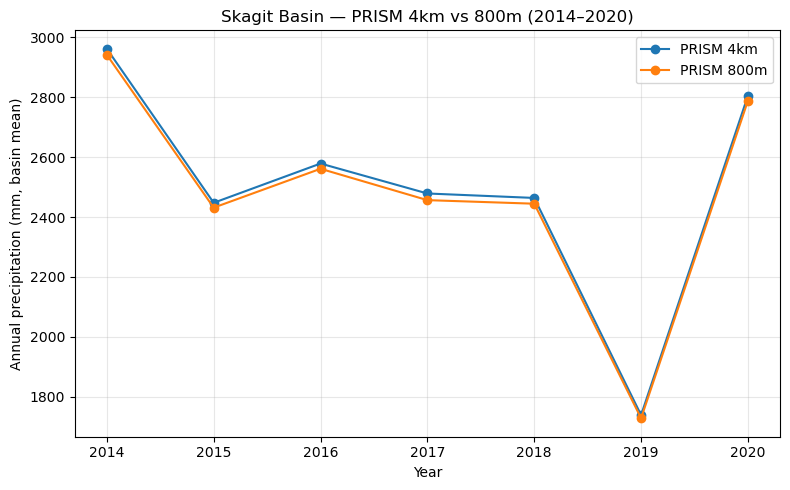

In [1]:
#!/usr/bin/env python
# compare_prism_4km_800m_annual.py
#
# Skagit Basin — Annual Precip (mm) from PRISM 4km vs PRISM 800m
# Years: 2014–2020
# Uses same helpers/pattern as the big "ALL datasets" script.

import json
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt


# ---------------- Config ----------------
BASE = Path("/data0/balaji24/data")

# 4km PRISM daily Zarrs (already downloaded)
P_PRISM4_DIR = BASE / "prism_ppt"

# 800m PRISM daily Zarrs (your new downloads)
P_PRISM8_DIR = BASE / "prism_ppt_800m"

# Skagit basin boundary
BOUNDARY_GEO = Path("../data/GIS/SkagitBoundary.json")

YEAR_MIN, YEAR_MAX = 2014, 2020

OUT = BASE / "derived"
OUT.mkdir(parents=True, exist_ok=True)
CSV_OUT = OUT / "annual_precip_skagit_2014_2020_PRISM_4km_800m.csv"
PNG_OUT = OUT / "annual_precip_skagit_2014_2020_PRISM_4km_800m.png"


# ---------------- Helpers (same style as big script) ----------------
def safe_open_zarr(p: Path):
    """Try consolidated=True first, then fallback to consolidated=False."""
    try:
        return xr.open_zarr(p, consolidated=True)
    except Exception:
        return xr.open_zarr(p, consolidated=False)


def find_lat_lon_names(ds):
    lat_name = next((n for n in ["lat", "latitude", "XLAT", "XLAT_M"] if n in ds), None)
    lon_name = next((n for n in ["lon", "longitude", "XLONG", "XLONG_M"] if n in ds), None)
    return lat_name, lon_name


def _load_boundary_geom():
    """Load Skagit basin polygon from GeoJSON (same logic as big script)."""
    from shapely.geometry import shape, Polygon, LinearRing

    with open(BOUNDARY_GEO) as f:
        obj = json.load(f)

    if isinstance(obj, dict) and "type" in obj:
        if obj["type"] == "FeatureCollection":
            return shape(obj["features"][0]["geometry"])
        elif obj["type"] == "Feature":
            return shape(obj["geometry"])
        else:
            return shape(obj)

    elif isinstance(obj, dict) and {"lon", "lat"} <= obj.keys():
        pts = list(zip(obj["lon"], obj["lat"]))
        if pts[0] != pts[-1]:
            pts.append(pts[0])
        return Polygon(LinearRing(pts))

    raise ValueError("Unrecognized boundary format in SkagitBoundary.json")


def skagit_mask(ds_with_latlon):
    """
    Build a boolean mask (True inside Skagit) on a dataset that has lat/lon.
    Uses regionmask like in the big script and is safe with 1D or 2D grids.
    """
    try:
        import regionmask
        import geopandas as gpd
    except Exception as e:
        print(f"[skagit_mask] Missing dependency ({e}), returning None (no mask).")
        return None

    lat_name, lon_name = find_lat_lon_names(ds_with_latlon)
    if not (lat_name and lon_name):
        print("[skagit_mask] Could not find lat/lon names, returning None.")
        return None

    def _to_2d(arr):
        # Drop a time dim if present (grid is static in time)
        if "time" in arr.dims:
            arr = arr.isel(time=0)
        # Drop any length-1 dims
        for d in list(arr.dims):
            if arr.sizes[d] == 1:
                arr = arr.isel({d: 0})
        # If still >2D (rare), keep slicing until 2D
        while arr.ndim > 2:
            extra = [d for d in arr.dims if d not in ("x", "y", "lon", "lat")]
            if not extra:
                break
            arr = arr.isel({extra[0]: 0})
        return arr

    lon = _to_2d(ds_with_latlon[lon_name])
    lat = _to_2d(ds_with_latlon[lat_name])

    # Load basin polygon
    geom = _load_boundary_geom()

    try:
        # Turn polygon into a Regions object
        gdf = gpd.GeoDataFrame({"name": ["Skagit"]}, geometry=[geom], crs="EPSG:4326")
        regions = regionmask.Regions.from_geopandas(gdf, names="name")
    except AttributeError:
        # Fallback if old regionmask API
        regions = regionmask.Regions(
            outlines=[geom], names=["Skagit"], numbers=[0], name="Skagit"
        )

    # regionmask works with 1D or 2D lon/lat
    m = regions.mask(lon, lat)  # NaN outside, 0 inside
    return m.isnull() == False  # True inside


def ensure_time_sorted_unique(da: xr.DataArray) -> xr.DataArray:
    """Sort by time & drop duplicate timestamps; safe for dask."""
    if "time" not in da.dims:
        return da
    da = da.sortby("time")
    try:
        t = xr.DataArray(da["time"].values)
        _, idx = np.unique(t.values, return_index=True)
        da = da.isel(time=np.sort(idx))
    except Exception:
        pass
    return da


def basin_mean(da: xr.DataArray, grid_ds: xr.Dataset | None = None) -> xr.DataArray:
    """
    Basin-average on the field's native grid using a Skagit mask.
    If mask creation fails, fall back to plain spatial mean.
    """
    # Identify time dimension
    time_dim = next(
        (d for d in da.dims if np.issubdtype(da[d].dtype, np.datetime64)), "time"
    )
    spatial = [d for d in da.dims if d != time_dim]
    if not spatial:
        return da

    host = grid_ds if grid_ds is not None else da.to_dataset(name="_tmp")
    mask = skagit_mask(host)

    if (mask is None) or (set(mask.dims) != set(spatial)):
        # fallback: mean over all grid cells
        return da.mean(spatial, skipna=True)

    w = xr.where(mask, 1.0, np.nan)
    return (da * w).mean(spatial, skipna=True)


def annual_sum_mm(da: xr.DataArray) -> xr.DataArray:
    """Sum daily precip to annual totals (mm/year)."""
    if "time" not in da.dims:
        out = xr.DataArray(da)
        out = out.rename("mm")
        return out

    years = da["time"].dt.year
    out = da.groupby(years).sum("time")
    out = out.rename({"group": "year"}) if "group" in out.dims else out

    # Normalize coord name if xarray uses 'time.year'
    if "time.year" in out.coords:
        out = out.rename({"time.year": "year"})

    out.name = "mm"
    return out


def pick_year(ann: xr.DataArray, yr: int) -> float:
    """Extract a single year's value from an annual array; return NaN if missing."""
    try:
        if "year" in ann.coords:
            return float(ann.sel(year=yr).values)
        # Fallback: find any coord whose name includes 'year'
        for c in ann.coords:
            if "year" in str(c):
                return float(ann.sel({c: yr}).values)
        return float(ann.values.item())  # single value
    except Exception:
        return np.nan


# ---------------- Core Collector ----------------
def collect_prism_annual(root: Path, pattern: str, label: str):
    """
    Generic PRISM collector: find Zarrs under `root` matching `pattern`,
    compute Skagit basin annual precip, and return list of dict rows.
    """
    rows = []

    if not root.exists():
        print(f"[{label}] Root directory {root} does not exist, skipping.")
        return rows

    zarrs = sorted(root.glob(pattern))
    if not zarrs:
        print(f"[{label}] No Zarrs found with pattern '{pattern}', skipping.")
        return rows

    print(f"[{label}] Found {len(zarrs)} Zarr(s). Concatenating along time lazily...")
    ds = xr.concat(
        [safe_open_zarr(p) for p in zarrs],
        dim="time",
        join="outer",
        coords="minimal",
        compat="override",
    )

    var_name = next((v for v in ["ppt", "precip", "prcp"] if v in ds), None)
    if var_name is None:
        print(f"[{label}] No ppt/precip/prcp variable found, skipping.")
        return rows

    da = ensure_time_sorted_unique(ds[var_name])  # mm/day
    print(f"[{label}] Using variable '{var_name}' with shape {da.shape}")

    # Basin mean daily precip
    bm = basin_mean(da, grid_ds=ds)  # 1D (time,)
    ann = annual_sum_mm(bm)          # annual totals

    for yr in range(YEAR_MIN, YEAR_MAX + 1):
        val = pick_year(ann, yr)
        if not np.isnan(val):
            rows.append({"dataset": label, "year": yr, "mm": val})

    print(f"[{label}] Collected {len(rows)} annual values.")
    return rows


def main():
    all_rows = []

    # PRISM 4km
    rows4 = collect_prism_annual(
        root=P_PRISM4_DIR,
        pattern="**/*_daily_4km_PRISM_data.zarr",
        label="PRISM 4km",
    )
    all_rows.extend(rows4)

    # PRISM 800m
    rows8 = collect_prism_annual(
        root=P_PRISM8_DIR,
        pattern="**/*_daily_800m_PRISM_data.zarr",
        label="PRISM 800m",
    )
    all_rows.extend(rows8)

    if not all_rows:
        print("No data collected for either dataset – nothing to save/plot.")
        return

    df = (
        pd.DataFrame(all_rows)
        .sort_values(["dataset", "year"])
        .reset_index(drop=True)
    )

    print("\n=== Annual Skagit Basin Precipitation (mm) ===")
    print(df)
    df.to_csv(CSV_OUT, index=False)
    print("Saved CSV →", CSV_OUT)

    # Plot
    plt.figure(figsize=(8, 5))
    for name, g in df.groupby("dataset"):
        plt.plot(g["year"], g["mm"], marker="o", label=name)

    plt.xlabel("Year")
    plt.ylabel("Annual precipitation (mm, basin mean)")
    plt.title("Skagit Basin — PRISM 4km vs 800m (2014–2020)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(PNG_OUT, dpi=160)
    print("Saved plot →", PNG_OUT)
    plt.show()


if __name__ == "__main__":
    main()